Using device: cuda
Stage 1 Training: VAE (SC + ST, Marker Genes)
Configuration:
   Marker genes per type: 200
   Clustering mode: Auto-cluster (Leiden)
   Leiden resolution: 0.5
   Precomputed marker genes: ./stage1_results/CID44971/final_genes.txt
   Batch size: 256
   Epochs: 50
   Learning rate: 0.001
   Beta (KL weight): 0.1
   Hidden dims: [512, 256]
   Latent dim: 256
   Loss type: ZINB
   Lambda MMD: 1.0
Loading datasets...
   Loading SC: /home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_SC.h5ad
   SC shape: (7986, 29733)
   Loading ST: /home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad
   ST shape: (1147, 23531)
   Common genes: 17415
   SC final: (7986, 17415)
   ST final: (1147, 17415)
Using precomputed marker genes from: ./stage1_results/CID44971/final_genes.txt
Loading marker genes from file: ./stage1_results/CID44971/final_genes.txt
   Loaded 1042 marker genes
Saved clustered SC adata: ./stage1_results/CID44971/sc_adata_clustere

VAE Training:   8%|▊         | 4/50 [00:03<00:36,  1.27epoch/s]

VAE Training: 100%|██████████| 50/50 [00:40<00:00,  1.24epoch/s, Train=1086.8603, Recon=1080.8646, KL=59.9519, MMD=0.0845, Test=1114.6808]


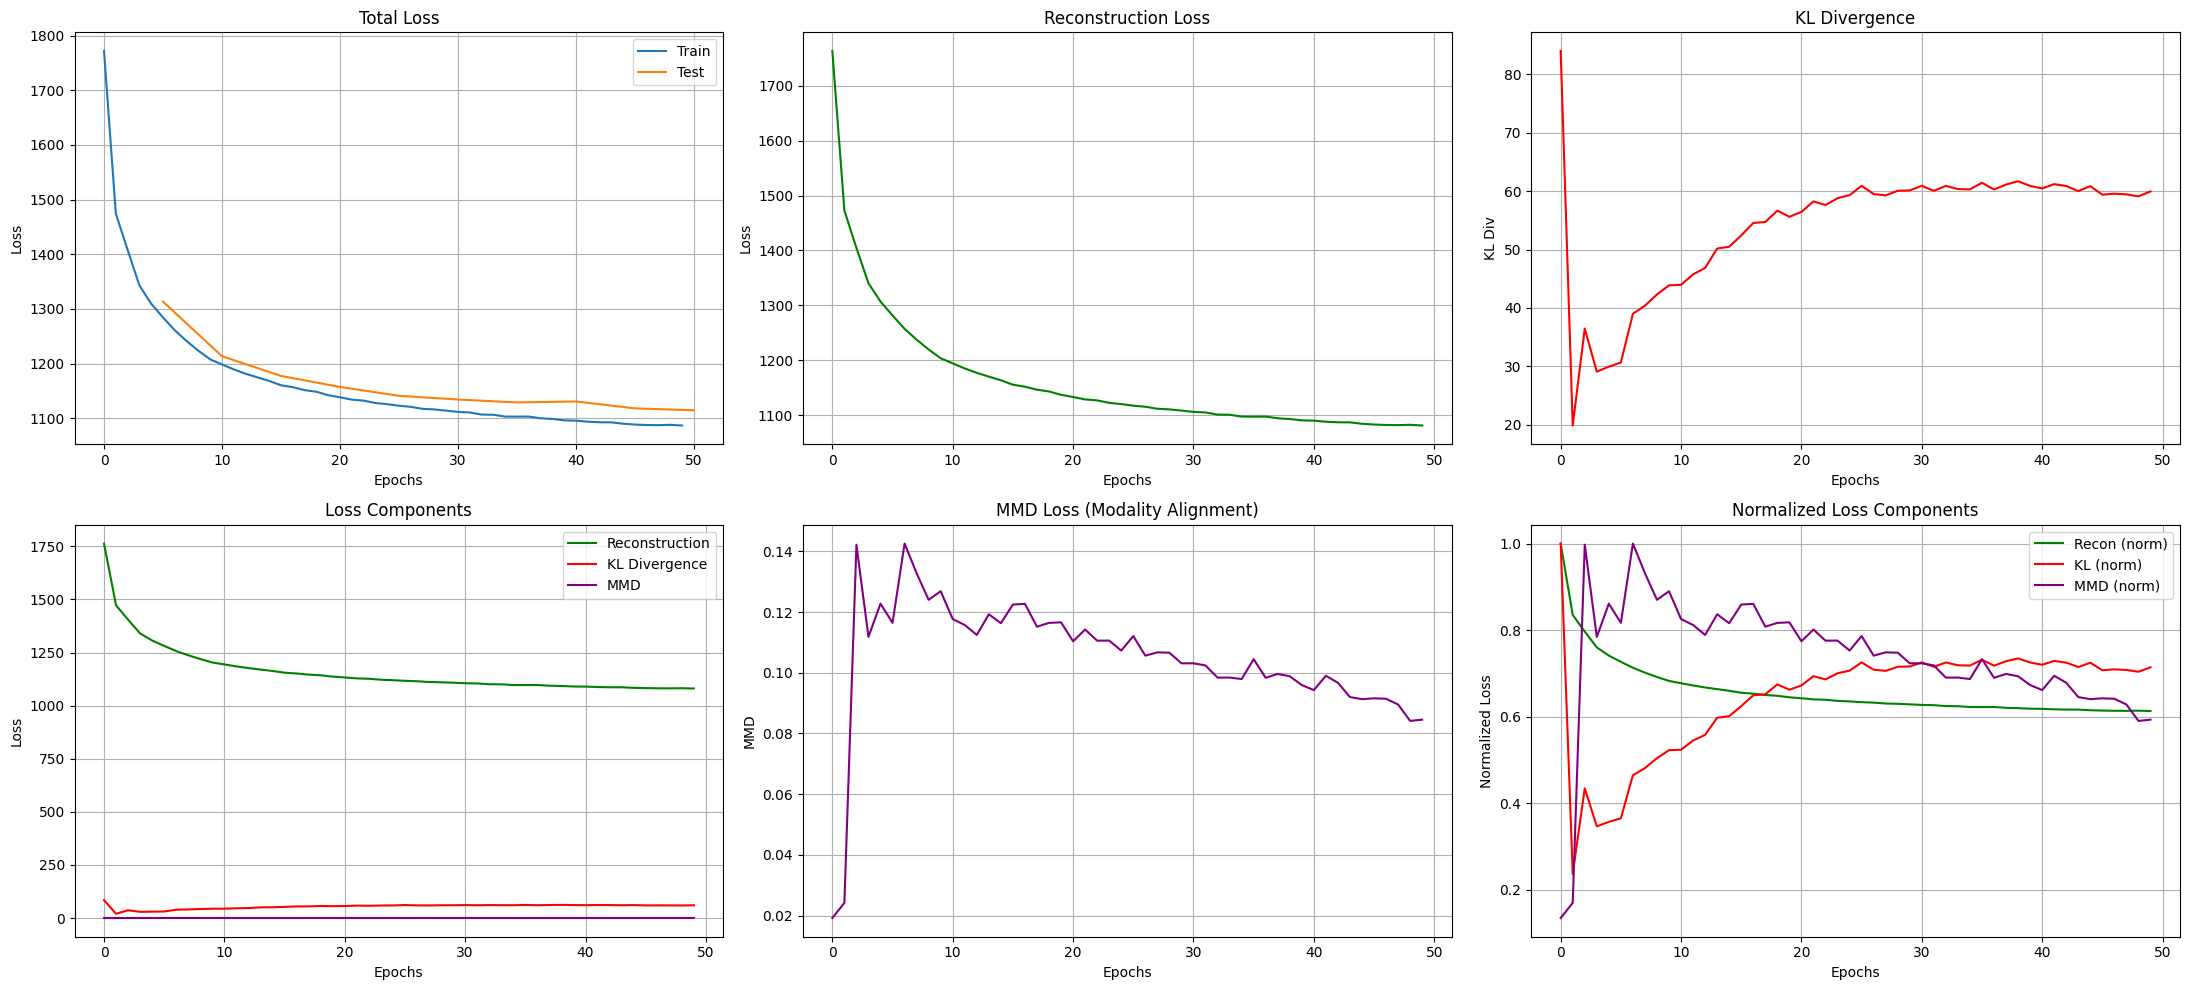

Computing cluster centers...
   SC training data: (7187, 1042)
   Number of clusters: 21
   Computing full gene cluster expressions...
      Total genes: 17415
   Completed: 21 clusters with center and expressions (all genes)
Visualizing modality alignment...
Generating UMAP visualization for modality alignment...
   Computing UMAP on 8219 samples with 256 dims...


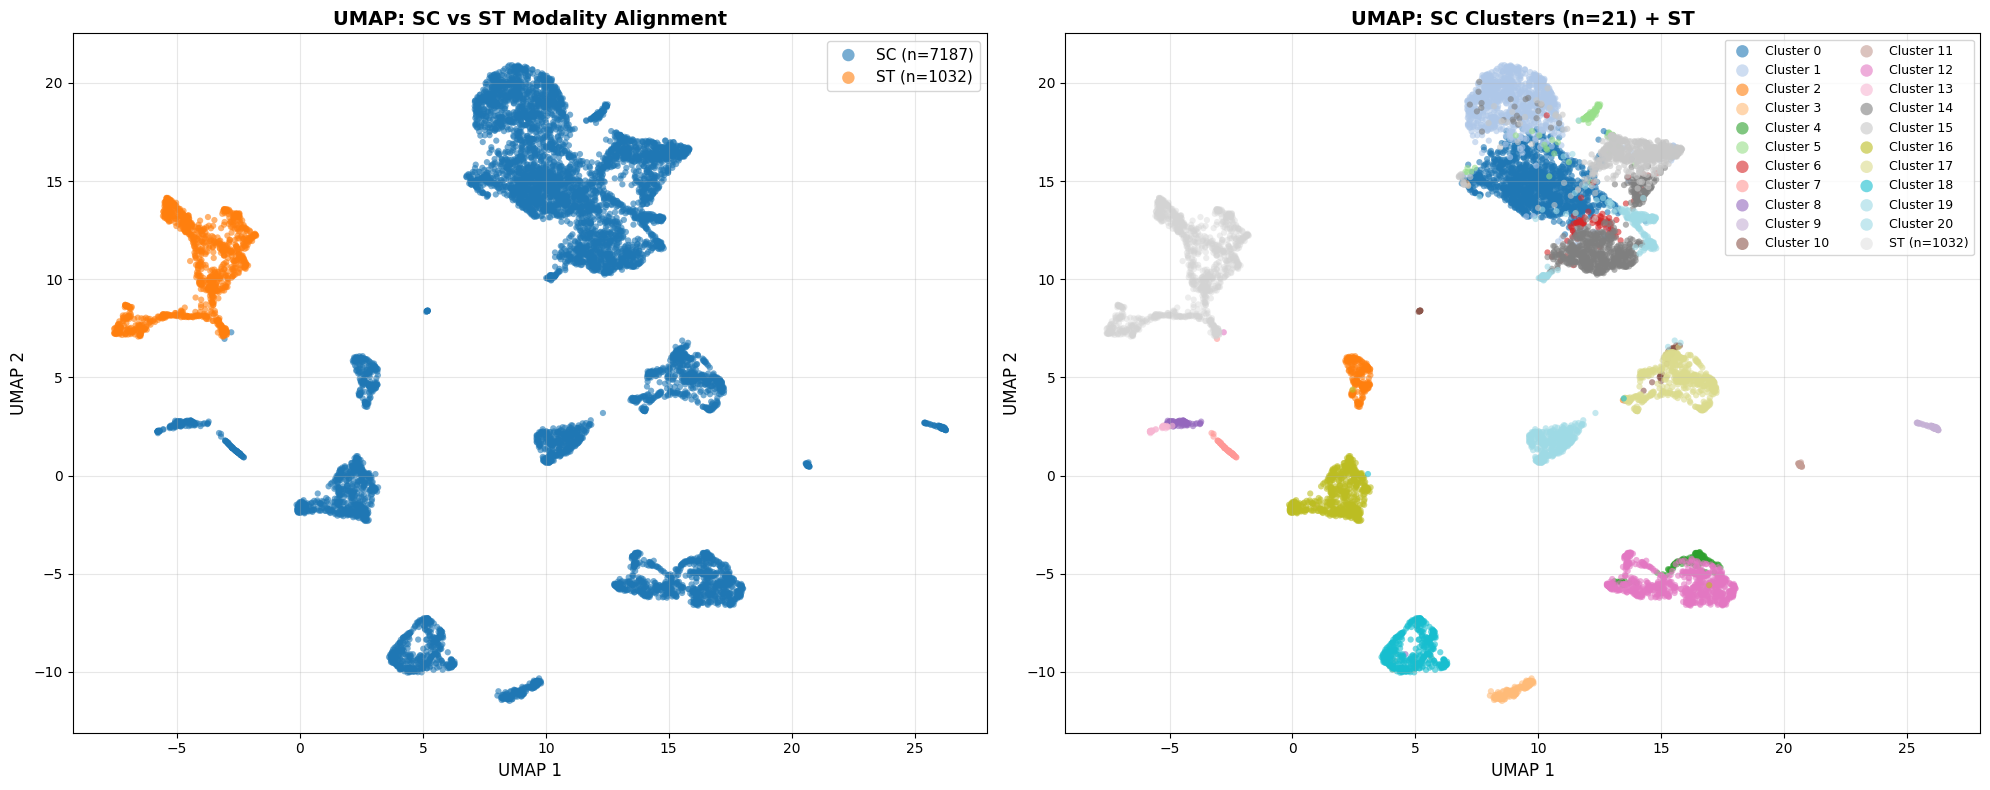

   UMAP visualization saved to: ./stage1_results/CID44971/modality_alignment_umap.png
Saving model to: ./stage1_results/CID44971/final_vae.pth
   Cluster centers: 21 clusters
   Cluster expressions (marker genes, count): 21 clusters
   Cluster expressions (all genes, count): 21 clusters
   Cluster expressions (all genes, count backup): 21 clusters


In [5]:
# epoch影响较大
%run stage1.py \
    --sc_file "/home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_SC.h5ad" \
    --st_file "/home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --n_epochs 50 \
    --resolution 0.5 \
    --loss_type zinb \
    --beta 0.1 \
    --lambda_mmd 1.0 \
    --top_n_per_type 200 \
    --latent_dim 256 \
    --output_dir ./stage1_results/CID44971 \
    --precomputed_marker_file ./stage1_results/CID44971/final_genes.txt

---

Sample name: CID44971
Stage 1 model: ./stage1_results/CID44971/final_vae.pth
Output directory: ./stage2_results/CID44971/
Device: cuda
Weight threshold: 0.01
Loading pretrained VAE Encoder...
   VAE architecture: 1042 -> 256
   Output type: zinb
Loaded cluster centers: torch.Size([21, 256])
Loaded cluster expressions: torch.Size([21, 1042])
Loaded full gene expressions (count): 21 clusters × 17415 genes
Loaded all genes list: 17415 genes
VAE Encoder loaded: 1042 -> 256
Cell type clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
Marker genes: 1042
Using Stage 1 cluster centers and expressions...
Loaded 21 clusters
Using Stage 1 pretrained cluster data
   Cluster centers: torch.Size([21, 256])
   Cluster expressions: torch.Size([21, 1042])
Loading and processing spatial transcriptomics data...
Loading ST data: /home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad
ST matching genes: 1042/10

GAT Training:   1%|          | 1/150 [00:02<05:09,  2.08s/epoch, Total=745.4902, Pearson=0.3342, MSE=744.8482, Cosine=0.3038, Align=0.0079]

GAT Training: 100%|██████████| 150/150 [04:33<00:00,  1.82s/epoch, Total=656.7743, Pearson=0.2662, MSE=656.1994, Cosine=0.2454, Align=0.1266]


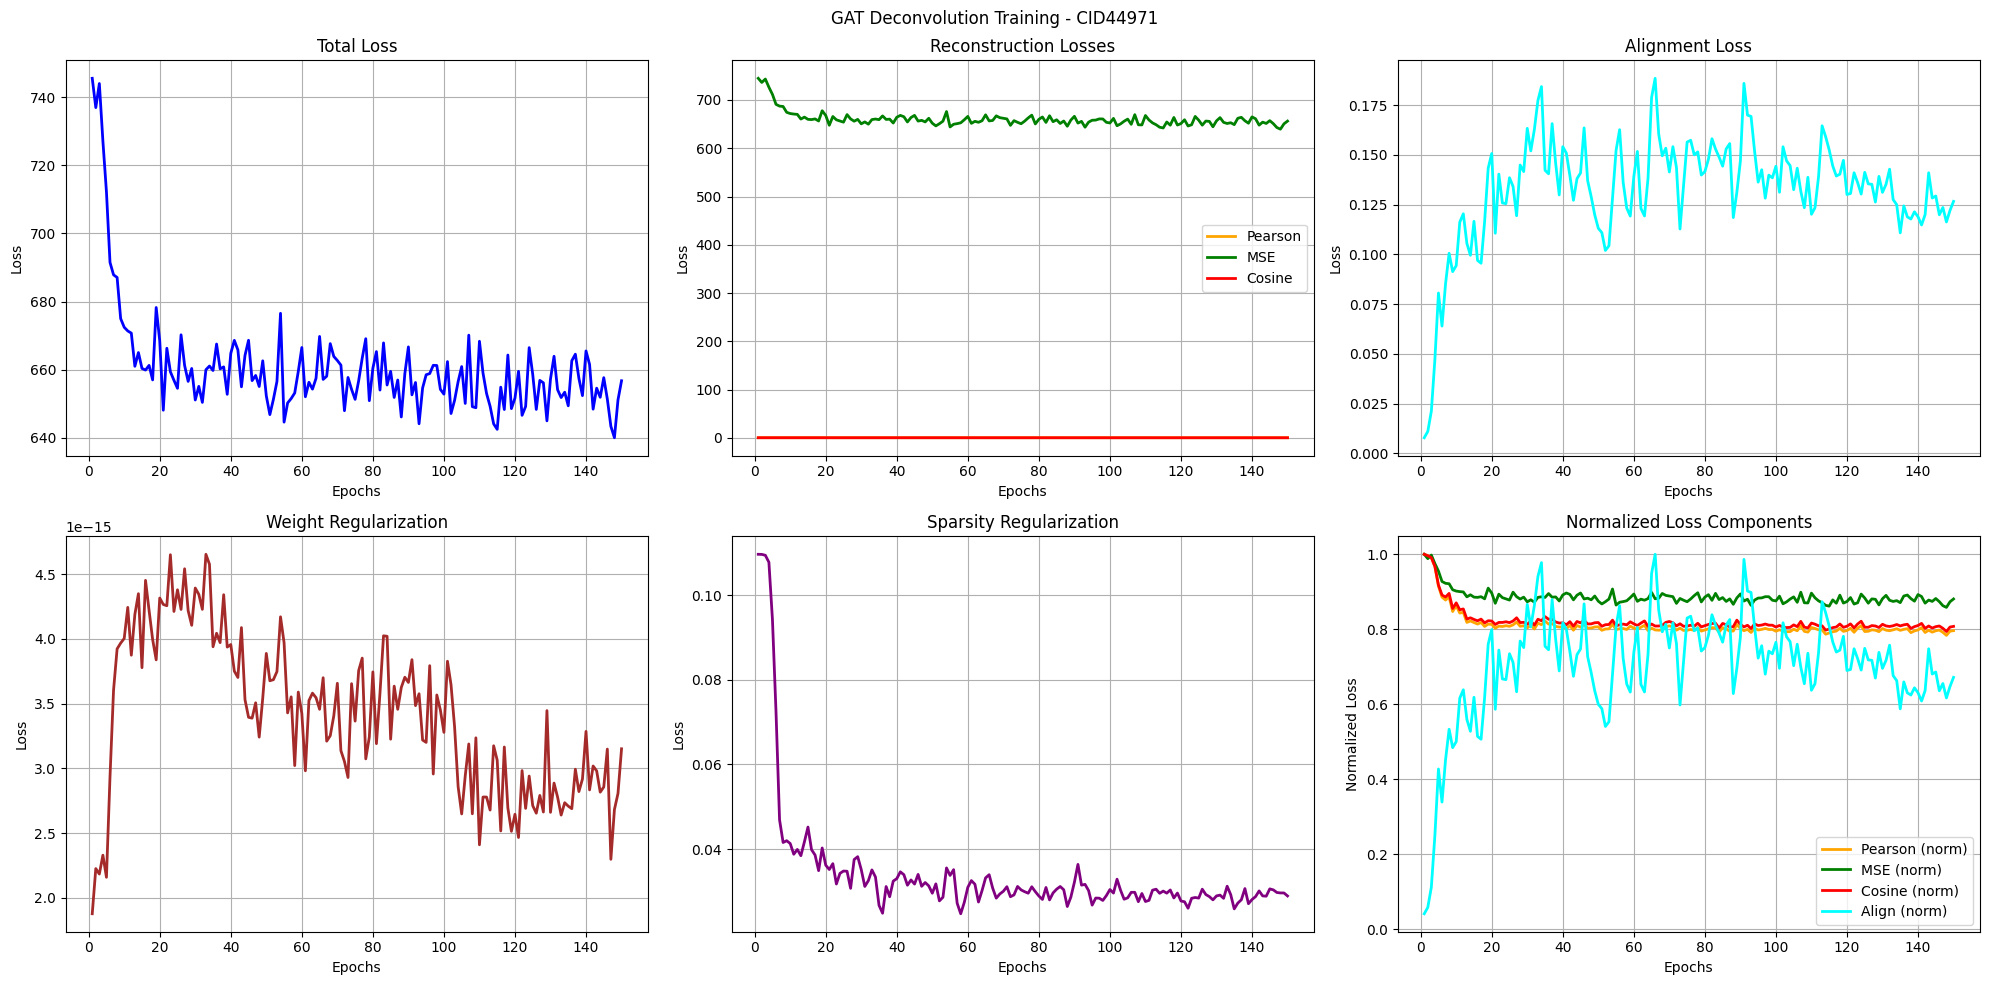

Evaluating model results...
Cells per spot: 10.0
Applying weight threshold: 0.01
   Non-zero elements: 11470 -> 4459 (18.5%)
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
   Full gene expression...
   Cell type composition...
   Found duplicate celltype names: ['Normal Epithelial', 'T-cells', 'Cancer Epithelial', 'Myeloid']. Merging corresponding cluster columns by summing weights.
   Columns before: 21, after merge: 9
   Saved cell composition (celltype): ./stage2_results/CID44971//CID44971_cell_composition.csv
   Saved cluster composition: ./stage2_results/CID44971//CID44971_cluster_composition.csv

Saving cluster expression data for train.py...
   ✅ Cluster marker gene expression: ./stage2_results/CID44971//CID44971_cluster_marker_expr.csv
   ✅ Cluster full gene expression: ./stage2_results/CID44971//CID44971_cluster_full_expr.csv
   ✅ Celltype-cluster mapping: ./stage2_results/CID44971//CID44971_celltype_cluster_mapping

In [ ]:
# k_celltype 影响比较大
%run stage2.py \
    --st_file "/home/maweicheng/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --stage1_model_path "./stage1_results/CID44971/final_vae.pth" \
    --output_dir "./stage2_results/CID44971/" \
    --gat_hidden_dim 256 \
    --gat_layers 4 \
    --lr 1e-4 \
    --loss_lambda_mse 1 \
    --loss_lambda_cosine 1 \
    --loss_lambda_align 0.5 \
    --loss_lambda_reg 0.1 \
    --loss_lambda_sparse 0.001 \
    --loss_lambda_pearson 1 \
    --k_spatial 10 \
    --k_celltype 10 \
    --batch_size 256 \
    --n_epochs 150 \
    --weight_threshold 0.01